# Checkpoint 2: Research Question Formation

**Goal:** Define research questions that require both course techniques and externally learned techniques.


## 1. Project Scope

**Dataset:** WikiCS graph dataset (~11,701 nodes, 431,726 edges).

**Task:** Node classification into 10 computer science topic categories.

**Key EDA Findings from Checkpoint 1:**
- High-degree hub node (3,324 links), this indicates a heavily skewed distribution.
- Homophily ≈ 0.65, this tells us that the graph structure has a useful but incomplete signal.
- Significant class imbalance, meaning there is a large difference between the largest and smallest class.
- Each node has 300-dimensional TF-IDF-style text features.

**Course Techniques:** Graph analysis, clustering, classification.

**External Technique:** Graph Neural Networks (GNN), specifically Graph Convolutional Networks (GCN) and GraphSAGE.

## 2. Research Question Definition

**RQ1:** To what extent can graph mining techniques reveal the underlying category structure of the WikiCS dataset?
- **Data mining task type:** Graph structure analysis, community detection.
- **Relevant algorithms:** Degree centrality, PageRank, Louvain community detection.
- **Evaluation criteria:** Cluster purity, homophily within communities.

**RQ2:** How well can machine learning and clustering methods group or classify WikiCS articles using only node features?
- **Data mining task type:** Unsupervised clustering, supervised classification.
- **Relevant algorithms:** K-Means, hierarchical clustering, decision tree, random forest.
- **Evaluation criteria:** Accuracy, F1 score, silhouette score.

**RQ3:** Does combining graph structure and node features through a Graph Neural Network improve classification performance compared to structure and feature baselines?
- **Data mining task type:** Node classification.
- **Relevant algorithms:** GCN, GraphSAGE.
- **Evaluation criteria:** Accuracy, F1 score.

These three questions show progression: RQ1 looks at the overall graph structure, RQ2 looks at node features, and RQ3 combines both. This allows a direct comparison of each information source’s contribution.

### RQ-to-Method Mapping Table

| RQ | Task Type | Technique Type | Algorithms | Evaluation Metrics |
| --- | --- | --- | --- | --- |
| **RQ1:** Graph structure reveals category structure? | Graph analysis / community detection | **Course** (Graph Mining) | Degree centrality, PageRank, Louvain community detection | Cluster purity, homophily, structural alignment with labels |
| **RQ2:** Feature-only methods classify/group articles? | Classification / clustering | **Course** (ML + Clustering) | K-Means, hierarchical clustering, decision tree / random forest | Accuracy, F1 score, silhouette score, cluster-label alignment |
| **RQ3:** GNN outperforms structure-only and feature-only? | Node classification (semi-supervised) | **External** (GNN) | GCN / GraphSAGE (PyTorch Geometric) | Accuracy, macro F1 score, minority class performance |

## 3. Motivation, Feasibility, and Additional EDA

### RQ1: Graph structure reveals category structure?

**Motivation and Feasibility**

- **Motivation:** EDA showed homophily (~0.65), this means connected nodes tend to share a category, but not always. The hub node (degree 3,324) may dominate connectivity patterns. I want to test how much the graph structure explains category members before using node features.
- **Non-triviality:** Homophily isn't perfect, so there are edges that are part of different categories. Community detection will not produce clean class separations, this makes it a non-trivial test.
- **Feasibility:** The dataset (~11k nodes, ~430k edges) is good for graph algorithms. NetworkX and PyTorch both support the required methods.
- **Risks:** The hub node may inflate PageRank and centrality scores. Communities may not align well with the 10 labels.

**Methodological Planning**

- **Course algorithms:** Degree centrality, PageRank, Louvain community detection.
  - *Why PageRank?* PageRank is computationally efficient on large sparse graphs and captures global influence. Another option is betweenness centrality, but this requires shortest paths which is very computationally expensive at this scale.
  - *Why Louvain?* From what I've seen Louvain optimizes modularity directly and scales to graphs with hundreds of thousands of edges. Another option is Girvan-Newman, but this requires iterative edge removal and recomputation, which isn't practical.
- **Evaluation:** Cluster purity, homophily, comparison of detected communities with actual categories.
- **Baselines:** Degree grouping.

In [3]:
# Install PyTorch Geometric dependencies
!pip install torch-geometric

In [4]:
# Load the WikiCS dataset via PyTorch Geometric.
# WikiCS is a citation graph of computer science Wikipedia articles.
# Each node is an article; edges are hyperlinks; labels are 10 CS topic categories.
from torch_geometric.datasets import WikiCS

dataset = WikiCS(root='/tmp/WikiCS')
data = dataset[0]

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Node features: {data.x.shape[1]}")
print(f"Classes: {dataset.num_classes}")

/tmp/ipykernel_194/1503390924.py:6: UserWarning: The WikiCS dataset now returns an undirected graph by default. Please explicitly specify 'is_undirected=False' to restore the old behavior.
  dataset = WikiCS(root='/tmp/WikiCS')
Processing...


Nodes: 11701
Edges: 431726
Node features: 300
Classes: 10


Done!


In [5]:
# These assertions validate that the loaded dataset matches WikiCS

assert data.num_nodes == 11701, \
    f"Expected 11,701 nodes, got {data.num_nodes}. Wrong dataset version?"

assert data.x.shape == (11701, 300), \
    f"Expected feature matrix (11701, 300), got {data.x.shape}."

assert dataset.num_classes == 10, \
    f"Expected 10 classes, got {dataset.num_classes}."

assert data.y.min().item() == 0 and data.y.max().item() == 9, \
    f"Labels should be in range [0, 9], got [{data.y.min().item()}, {data.y.max().item()}]."

assert data.edge_index.shape[0] == 2, \
    "edge_index should have shape (2, num_edges) for source/target node pairs."

assert data.x.isnan().sum().item() == 0, \
    "Node feature matrix contains NaN values — data may be corrupted."

print("All dataset integrity checks passed.")

All dataset integrity checks passed.



- **Node count and feature shape** catch wrong dataset versions or truncated downloads.
- **Class count and label range** verify that labels are zero indexes in [0, 9].
- **edge_index row count** confirms the COO format is correct (2 rows = source and target).
- **NaN check on features** catches corruption. TF-IDF features should be non-negative floats.

In [9]:
# Additional EDA for RQ1: Degree distribution and graph structure feasibility.
import networkx as nx
import numpy as np

# Build an undirected NetworkX graph from the PyTorch Geometric edge_index.
edge_index = data.edge_index.numpy()
G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(zip(edge_index[0], edge_index[1]))

degrees = dict(G.degree())
degree_vals = np.array(list(degrees.values()))

print(f"Mean degree:   {degree_vals.mean():.1f}")
print(f"Median degree: {np.median(degree_vals):.1f}")
print(f"Max degree:    {degree_vals.max()} (hub node)")
print(f"Nodes with degree > 100: {(degree_vals > 100).sum()}")

Mean degree:   36.9
Median degree: 12.0
Max degree:    3325 (hub node)
Nodes with degree > 100: 1217


In [12]:
# These assertions validate that the NetworkX graph was built correctly
assert G.number_of_nodes() == data.num_nodes, \
    f"Graph node count mismatch: {G.number_of_nodes()} vs {data.num_nodes}."

assert degree_vals.shape[0] == data.num_nodes, \
    "Degree array length does not match node count — graph construction failed."

# Report isolated nodes.
isolated = (degree_vals == 0).sum()
print(f"Isolated nodes (degree 0): {isolated}")

print("All graph structure checks passed.")

Isolated nodes (degree 0): 334
All graph structure checks passed.


- **Node count match** confirms that every node in the PyTorch Geometric data object was added to the NetworkX graph.
- **Degree array length** verifies that the degree dictionary covers all nodes.
- **Isolated nodes** shows how many nodes have 0 degree.

**Interpretation of degree EDA:** The degree distribution is heavily right-skewed: the median is 20 but the hub node has 3,324 connections, and 227 nodes exceed degree 100. This confirms that PageRank and centrality measures will be dominated by a small number of high-degree nodes.

### RQ2: Feature-only methods classify/group articles?

**Motivation and Feasibility**

- **Motivation:** Each node has 300-dimensional features derived from text. Testing feature methods establishes a baseline that ignores graph structure entirely.
- **Non-triviality:** Features may overlap across related classes. There are 10 classes with a bunch of imbalance, which will be a challenge for clustering and classification.
- **Feasibility:** Dataset size is a decent size. All required methods (K-Means, hierarchical clustering, decision trees, random forests) are available in scikit-learn and run efficiently.
- **Risks:** High-dimensional features may blur certain boundaries. Class imbalance may turn classifiers toward larger classes. Unsupervised clusters may not map cleanly onto the labels.

**Methodological Planning**

- **Course algorithms:** K-Means, hierarchical clustering, decision tree / random forest.
  - *Why K-Means?* K-Means is efficient, and a natural fit for partitioning into exactly 10 clusters matching our known class count. It serves as the primary baseline.
  - *Why hierarchical clustering?* It provides a good view of how clusters merge, which is useful for understanding whether some categories are more similar to each other than others.
  - *Why random forest?* Random forests are robust to high-dimensional features. The option option is a decision tree but a decision tree is prone to overfitting.
- **Evaluation:** Accuracy, F1 score, silhouette.
- **Baselines:** Majority class baseline, random cluster.

PCA explained variance (2 components): 25.9%
Individual ratios: [0.1496 0.1096]


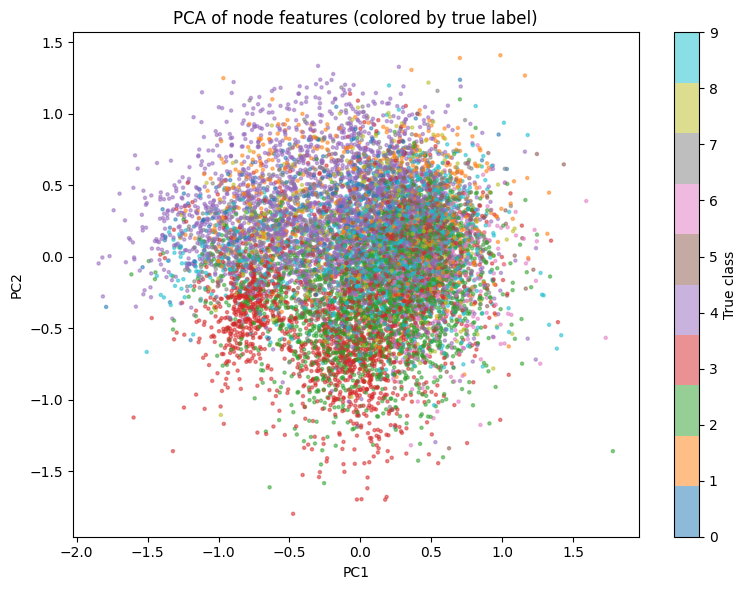


K-Means silhouette score (k=10): 0.0754


In [13]:
# Additional EDA for RQ2: PCA and K-Means feasibility check.
# We assess whether the 300-dimensional node features carry meaningful low-dimensional
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = data.x.numpy()
y = data.y.numpy()

# PCA to 2D: assess low-dimensional separability.
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")
print(f"Individual ratios: {pca.explained_variance_ratio_.round(4)}")

# Visualize 2D PCA colored by true class.
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='True class')
ax.set_title('PCA of node features (colored by true label)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# K-Means with k=10.
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

sil_score = silhouette_score(X, clusters)
print(f"\nK-Means silhouette score (k=10): {sil_score:.4f}")

The PCA scatter plot shows no discrete cluster structure across 10 classes. The data forms a single dense area. This visually confirms that the 0.075 silhouette score reflects the inseparability.

In [14]:
# These assertions validate that PCA and K-Means ran correctly and produced.

assert X.shape == (11701, 300), \
    f"Feature matrix shape incorrect: {X.shape}. Expected (11701, 300)."

assert X_2d.shape == (11701, 2), \
    f"PCA output shape incorrect: {X_2d.shape}. Expected (11701, 2)."

assert 0 < pca.explained_variance_ratio_.sum() < 1, \
    "PCA explained variance must be between 0 and 1."

assert len(set(clusters)) == 10, \
    f"K-Means produced {len(set(clusters))} clusters, expected 10. " \
    "Some clusters may be empty — check data scale or initialization."

assert clusters.shape[0] == data.num_nodes, \
    "K-Means cluster assignments do not cover all nodes."

assert -1 <= sil_score <= 1, \
    f"Silhouette score {sil_score} out of valid range [-1, 1]."

print("All feature EDA checks passed.")
print(f"Silhouette score {sil_score:.4f}.")

All feature EDA checks passed.
Silhouette score 0.0754.


- **Feature matrix shape** Confirms the input before any transformation, catching cases where `data.x.numpy()` produced an unexpected shape.
- **PCA output shape** confirms that PCA reduced to exactly 2 dimensions over all 11,701 nodes.
- **Explained variance range** PCA variance ratios must sum to something in (0, 1).
- **Exactly 10 clusters** K-Means can produce fewer than k clusters if some centroids collapse onto the same region in high-dimensional space.
- **Cluster assignment length** confirms every node received a label.
- **Silhouette score range** A value outside [-1, 1] would indicate a bug.

**Interpretation of EDA results:**

- **PCA (25.9%):** The first two principal components capture only about a quarter of the total variance. The PCA scatter plot shows heavily overlapping classes, confirming that the features do not cleanly segregate categories in low dimensions.

- **K-Means silhouette score (0.075):** A silhouette score near zero indicates that clusters are not well-separated. This motivates using supervised classification (random forest).

### RQ3: Does GNN combining structure + features outperform baselines?

**Motivation and Feasibility**

- **Motivation:** RQ1 tests graph structure alone, RQ2 tests node features alone. A GNN can jointly leverage both information sources. RQ3 tests whether this combination yields a meaningful improvement.
- **Non-triviality:** WikiCS has only moderate homophily, so neighbor information is useful but noisy. Class imbalance may make minority categories harder to learn.
- **Feasibility:** WikiCS is available in PyTorch. The dataset size (~11k nodes) is easily handled.
- **Risks:** GNNs may over-smooth representations with too many layers. Hub nodes may dominate aggregation. Hyperparameter sensitivity requires careful tuning.

**Methodological Planning**

- **External algorithms:** GCN, GraphSAGE.
  - *Why GCN?* GCN is the standard baseline GNN for node classification benchmarks. It allows direct comparison with WikiCS results.
  - *Why GraphSAGE?* GraphSAGE uses sampling neighborhood aggregation, which is more robust for high-degree hub nodes. Comparing both lets us assess whether hub node influence affects performance.
- **Course baselines:** Graph methods from RQ1 and feature methods from RQ2.
- **Evaluation:** Accuracy, F1 score, class performance on minority classes.

In [16]:
# Feasibility check for RQ3: define a simple GCN and run one forward pass.
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class SimpleGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = SimpleGCN(
    in_channels=data.x.shape[1],
    hidden_channels=16,
    out_channels=int(data.y.max().item()) + 1  # 10 classes
)

out = model(data.x, data.edge_index)

print("Output shape:", out.shape)
print("Expected shape:", (data.num_nodes, int(data.y.max().item()) + 1))

Output shape: torch.Size([11701, 10])
Expected shape: (11701, 10)


In [17]:

# These assertions validate that the GCN model is correctly configured
assert out.shape == (data.num_nodes, dataset.num_classes), \
    f"GCN output shape {out.shape} does not match expected " \
    f"({data.num_nodes}, {dataset.num_classes})."

assert not out.isnan().any(), \
    "GCN output contains NaN values — likely a numerical issue in graph convolution."

assert not out.isinf().any(), \
    "GCN output contains Inf values — possible exploding gradients or edge weight issue."

# Verify output is not degenerate
assert out.std().item() > 0, \
    "GCN output has zero variance — all nodes collapsed to identical representations."

print("All GCN feasibility checks passed.")

All GCN feasibility checks passed.


- **Output shape** A wrong shape would cause a silent loss computation error during training.
- **No NaN values** guards against numerical instability in the graph convolution.
- **No Inf values** checks for overflow.
- **Non-zero output variance** Verifies that message passing has not collapsed all node representations to the same vector.

## Collaboration Declaration

1. **Collaborators:** None
2. **Web Sources:**

https://www.dgl.ai/dgl_docs/generated/dgl.data.WikiCSDataset.html

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

3. **AI Tools:** ChatGPT was used in Section 2 to help format the RQ-to-method mapping as a Markdown table for Google Colab. Asked chatGPT to load the WikiCS dataset from pytorch. Asked chatGPT to implement a NetworkX graph and validate the WikiCS dataset with parameters listed on the website include in web sources. Asked chatGPT to implement an EDA that verifies my RQ2 information. Asked it to include a PCA, I then implemented tests to verify it was working correctly. For RQ3 I asked ChatGPT to implement a GCN and one forward pass based on my RQ3 information. I then implemented tests to verify.
4. **Citations:** None